In [1]:
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, Subset
from torchvision import datasets, models, transforms
from sklearn.model_selection import train_test_split
from pathlib import Path

torch.manual_seed(42)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using:", device)

Using: cuda


In [ ]:
DATA_DIR = Path.home()/"Downloads"/"new_CatsandDogs"   
NUM_CLASSES = 37

IMG_SIZE = 224
NORM_MEAN = [0.485, 0.456, 0.406]
NORM_STD = [0.229, 0.224, 0.225]

transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(NORM_MEAN, NORM_STD),
])

data = datasets.ImageFolder(DATA_DIR, transform=transform)

class_names = data.classes
labels = data.targets
assert len(class_names) == NUM_CLASSES, f"expected {NUM_CLASSES} breed folders in {DATA_DIR}, found {len(class_names)}"

idx_train, idx_rest = train_test_split(
    list(range(len(labels))), test_size=0.30, random_state=42, stratify=labels)
idx_val, idx_test = train_test_split(
    idx_rest, test_size=0.50, random_state=42, stratify=[labels[i] for i in idx_rest])

train_ds = Subset(data, idx_train)
val_ds = Subset(data, idx_val)
test_ds = Subset(data, idx_test)

train_loader = DataLoader(train_ds, batch_size=32, shuffle=True)
val_loader = DataLoader(val_ds, batch_size=32)
test_loader = DataLoader(test_ds, batch_size=32)

print(f"{len(class_names)} classes: {class_names}")
print(f"{len(labels)} images total -> train {len(train_ds)} | val {len(val_ds)} | test {len(test_ds)}")

print(f"\n{'breed':<28}{'train':>7}{'val':>6}{'test':>6}")
for c, name in enumerate(class_names):
    row = [sum(1 for i in idx if labels[i] == c) for idx in (idx_train, idx_val, idx_test)]
    print(f"{name:<28}{row[0]:>7}{row[1]:>6}{row[2]:>6}")

assert not (set(idx_train) & set(idx_val) & set(idx_test))
assert len(set(idx_train) | set(idx_val) | set(idx_test)) == len(labels)

37 classes: ['Abyssinian', 'Bengal', 'Birman', 'Bombay', 'British_Shorthair', 'Egyptian_Mau', 'Maine_Coon', 'Persian', 'Ragdoll', 'Russian_Blue', 'Siamese', 'Sphynx', 'american_bulldog', 'american_pit_bull_terrier', 'basset_hound', 'beagle', 'boxer', 'chihuahua', 'english_cocker_spaniel', 'english_setter', 'german_shorthaired', 'great_pyrenees', 'havanese', 'japanese_chin', 'keeshond', 'leonberger', 'miniature_pinscher', 'newfoundland', 'pomeranian', 'pug', 'saint_bernard', 'samoyed', 'scottish_terrier', 'shiba_inu', 'staffordshire_bull_terrier', 'wheaten_terrier', 'yorkshire_terrier']
7315 images total -> train 5120 | val 1097 | test 1098

breed                         train   val  test
Abyssinian                      136    29    29
Bengal                          140    30    30
Birman                          139    30    30
Bombay                          123    27    26
British_Shorthair               139    29    30
Egyptian_Mau                    135    29    28
Maine_Coon     

In [ ]:
model = models.resnet18(weights="DEFAULT")                 
model.fc = nn.Linear(model.fc.in_features, NUM_CLASSES)    
model = model.to(device)

print(f"resnet18 final layer: {model.fc}")

resnet18 final layer: Linear(in_features=512, out_features=37, bias=True)


In [ ]:
model.eval()
correct = 0
with torch.no_grad():
    for x, y in test_loader:
        pred = model(x.to(device)).argmax(1).cpu()
        correct += (pred == y).sum().item()

print(f"test accuracy with no training = {correct / len(test_ds):.3f}  ({correct} of {len(test_ds)} correct)")
print(f"random guessing over {NUM_CLASSES} breeds = {1 / NUM_CLASSES:.3f}")

test accuracy with no training = 0.021  (23 of 1098 correct)
random guessing over 37 breeds = 0.027


test accuracy = 0.021  (no training - the new fc layer still has random weights)
1075 wrong out of 1098 images

                            precision    recall  f1-score   support

                Abyssinian      0.000     0.000     0.000        29
                    Bengal      0.026     0.033     0.029        30
                    Birman      0.000     0.000     0.000        30
                    Bombay      0.016     0.038     0.023        26
         British_Shorthair      0.000     0.000     0.000        30
              Egyptian_Mau      0.000     0.000     0.000        28
                Maine_Coon      0.000     0.000     0.000        30
                   Persian      0.000     0.000     0.000        30
                   Ragdoll      0.000     0.000     0.000        30
              Russian_Blue      0.063     0.467     0.112        30
                   Siamese      0.000     0.000     0.000        30
                    Sphynx      0.000     0.000     0.000        30
   

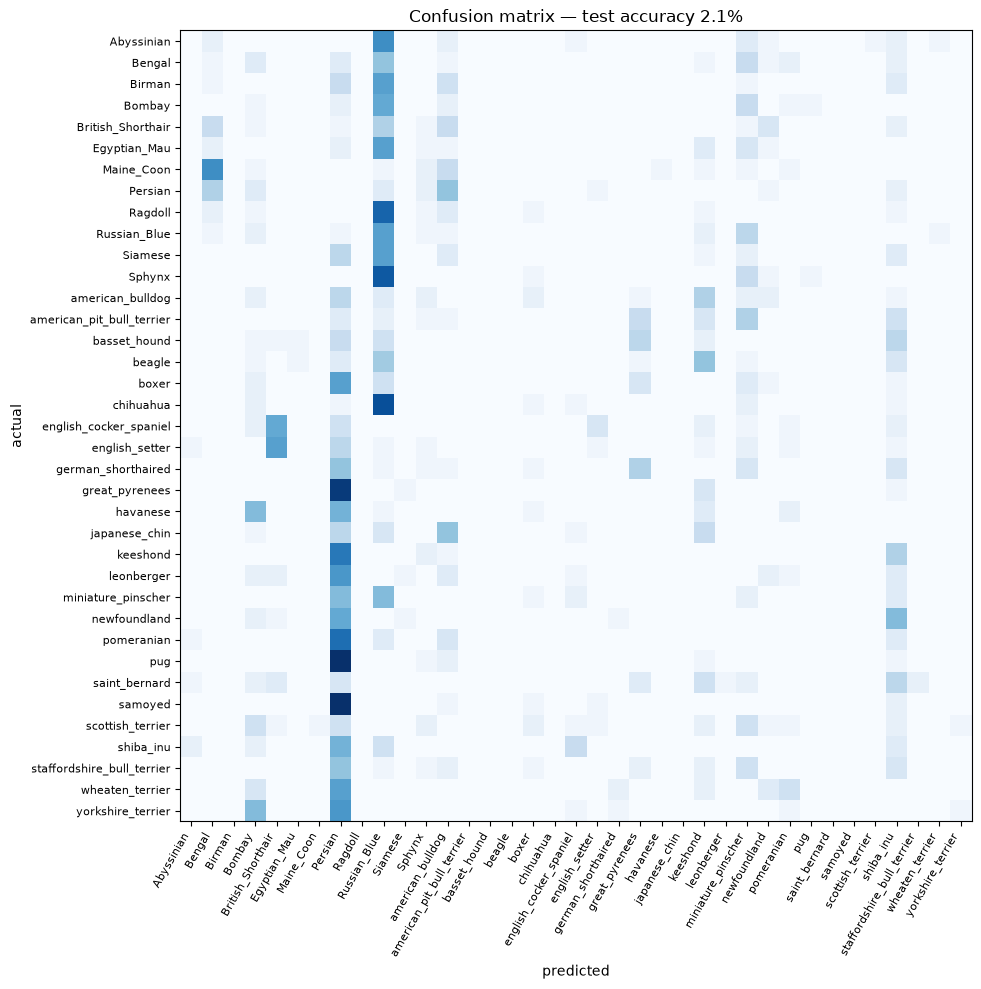

Most confused pairs (actual -> predicted):
  samoyed -> Persian  25 images
  pug -> Persian  25 images
  great_pyrenees -> Persian  24 images
  chihuahua -> Russian_Blue  22 images
  Sphynx -> Russian_Blue  21 images
  Ragdoll -> Russian_Blue  20 images
  pomeranian -> Persian  19 images
  keeshond -> Persian  18 images
  Maine_Coon -> Bengal  16 images
  Abyssinian -> Russian_Blue  16 images


In [5]:
import matplotlib.pyplot as plt
from sklearn.metrics import classification_report, confusion_matrix


@torch.no_grad()
def collect(loader):
    model.eval()
    ys, preds = [], []
    for x, y in loader:
        preds.append(model(x.to(device)).argmax(1).cpu())
        ys.append(y)
    return torch.cat(ys).numpy(), torch.cat(preds).numpy()


y_true, y_pred = collect(test_loader)
test_acc = (y_true == y_pred).mean()

print(f"test accuracy = {test_acc:.3f}  (no training - the new fc layer still has random weights)")
print(f"{int((y_true != y_pred).sum())} wrong out of {len(y_true)} images\n")

print(classification_report(y_true, y_pred, target_names=class_names, digits=3, zero_division=0))

cm = confusion_matrix(y_true, y_pred)
fig, ax = plt.subplots(figsize=(12, 10))
ax.imshow(cm, cmap="Blues")
ax.set_xticks(range(len(class_names)), class_names, rotation=60, ha="right", fontsize=8)
ax.set_yticks(range(len(class_names)), class_names, fontsize=8)
ax.set_xlabel("predicted")
ax.set_ylabel("actual")
ax.set_title(f"Confusion matrix — test accuracy {test_acc:.1%}")
plt.tight_layout()
plt.show()

mistakes = [(cm[i, j], class_names[i], class_names[j])
            for i in range(len(class_names)) for j in range(len(class_names)) if i != j and cm[i, j]]
if mistakes:
    print("Most confused pairs (actual -> predicted):")
    for n, a, b in sorted(mistakes, reverse=True)[:10]:
        print(f"  {a} -> {b}  {n} images")
else:
    print("No misclassified images in the test set")

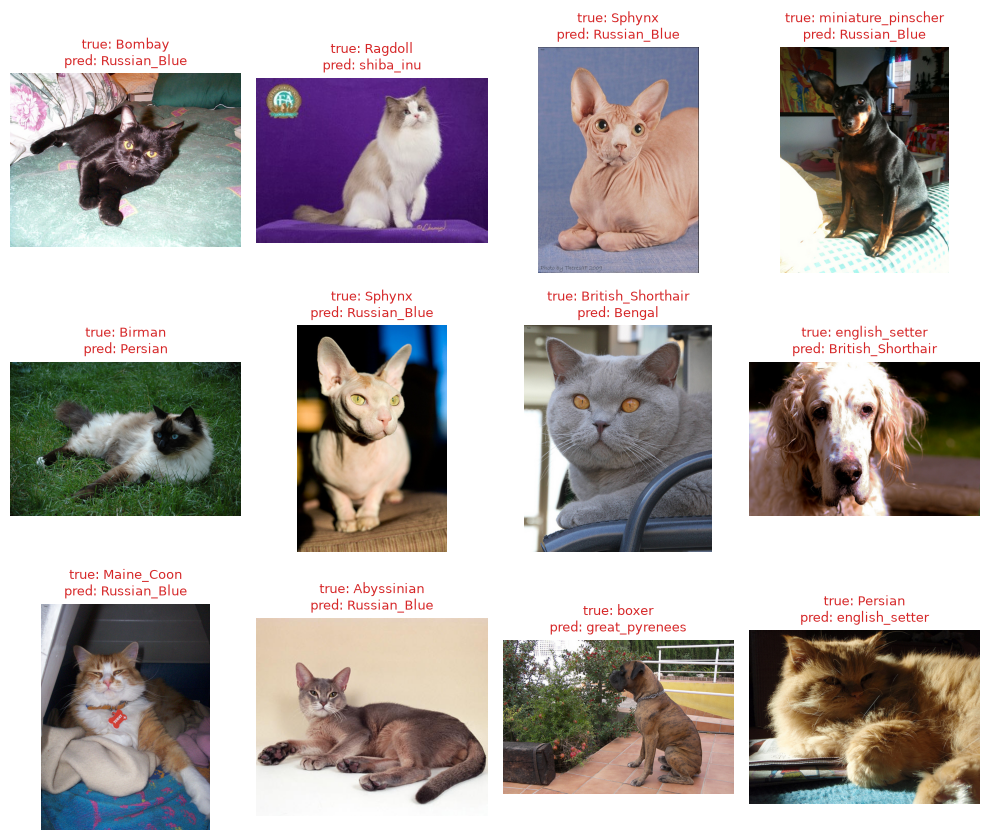

showing 12 of 1075 wrong test images


In [ ]:
from PIL import Image

wrong = [k for k in range(len(y_true)) if y_true[k] != y_pred[k]]

fig, axes = plt.subplots(3, 4, figsize=(10, 8.5))
for ax in axes.flat:
    ax.axis("off")
for ax, k in zip(axes.flat, wrong):
    path = data.samples[idx_test[k]][0]          
    ax.imshow(Image.open(path).convert("RGB"))
    ax.set_title(f"true: {class_names[y_true[k]]}\npred: {class_names[y_pred[k]]}", fontsize=9, color="tab:red")
plt.tight_layout()
plt.show()

print(f"showing {min(len(wrong), 12)} of {len(wrong)} wrong test images")

In [ ]:
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
from torchvision import models, transforms
from PIL import Image, ImageOps
from pathlib import Path

CKPT_PATH = "simple_model.pth"
NUM_CLASSES = 37


def load_model(path=CKPT_PATH):
    ckpt = torch.load(path, map_location="cpu", weights_only=True)
    names = ckpt["class_names"]
    assert len(names) == NUM_CLASSES, (
        f"{path} holds an old {len(names)}-class model - run the training cells above first to save the 37-breed model")

    net = models.resnet18()                                   
    net.fc = nn.Linear(net.fc.in_features, NUM_CLASSES)       
    net.load_state_dict(ckpt["model_state"])

    dev = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    net.to(dev).eval()

    tf = transforms.Compose([
        transforms.Resize((ckpt["img_size"], ckpt["img_size"])),
        transforms.ToTensor(),
        transforms.Normalize(ckpt["norm_mean"], ckpt["norm_std"]),
    ])
    return net, tf, names, dev, ckpt


net, tf, names, dev, ckpt = load_model()

print(f"Loaded the model from {CKPT_PATH}")
print(f"  architecture : resnet18, final layer {net.fc.in_features} -> {net.fc.out_features}")
print(f"  {len(names)} classes   : {names}")
print(f"  trained to   : epoch {ckpt['epoch']} (val accuracy {ckpt['val_accuracy']:.3f})")
print(f"  preprocessing: resize {ckpt['img_size']}x{ckpt['img_size']} + normalize")
print(f"  predicting on: {dev}")

Loaded the model from simple_model.pth
  architecture : resnet18, final layer 512 -> 37
  37 classes   : ['Abyssinian', 'Bengal', 'Birman', 'Bombay', 'British_Shorthair', 'Egyptian_Mau', 'Maine_Coon', 'Persian', 'Ragdoll', 'Russian_Blue', 'Siamese', 'Sphynx', 'american_bulldog', 'american_pit_bull_terrier', 'basset_hound', 'beagle', 'boxer', 'chihuahua', 'english_cocker_spaniel', 'english_setter', 'german_shorthaired', 'great_pyrenees', 'havanese', 'japanese_chin', 'keeshond', 'leonberger', 'miniature_pinscher', 'newfoundland', 'pomeranian', 'pug', 'saint_bernard', 'samoyed', 'scottish_terrier', 'shiba_inu', 'staffordshire_bull_terrier', 'wheaten_terrier', 'yorkshire_terrier']
  trained to   : epoch 5 (val accuracy 0.916)
  preprocessing: resize 224x224 + normalize
  predicting on: cuda


In [ ]:
from torch.utils.data import DataLoader, Subset
from torchvision import datasets
from sklearn.model_selection import train_test_split

DATA_DIR = Path.home() / "Downloads" / "new_CatsandDogs"

data = datasets.ImageFolder(DATA_DIR, transform=tf)
assert data.classes == names, (
    f"{CKPT_PATH} was not trained on these {len(data.classes)} breeds - re-run the training cells to save it again")

labels = data.targets
idx_train, idx_rest = train_test_split(
    list(range(len(labels))), test_size=0.30, random_state=42, stratify=labels)
idx_val, idx_test = train_test_split(
    idx_rest, test_size=0.50, random_state=42, stratify=[labels[i] for i in idx_rest])


@torch.no_grad()
def count_correct(idx):
    correct = 0
    for x, y in DataLoader(Subset(data, idx), batch_size=32):
        pred = net(x.to(dev)).argmax(1).cpu()
        correct += (pred == y).sum().item()
    return correct


print(f"resnet18 accuracy on {DATA_DIR.name} ({len(names)} breeds)\n")
print(f"{'split':<8}{'images':>8}{'correct':>9}{'wrong':>7}{'accuracy':>10}")

all_correct = 0
for split, idx in [("train", idx_train), ("val", idx_val), ("test", idx_test)]:
    correct = count_correct(idx)
    all_correct += correct
    print(f"{split:<8}{len(idx):>8}{correct:>9}{len(idx) - correct:>7}{correct / len(idx):>10.3f}")
print(f"{'all':<8}{len(labels):>8}{all_correct:>9}{len(labels) - all_correct:>7}{all_correct / len(labels):>10.3f}")

print("\nReport the test number: the model learned from train, and val was used to pick the epoch")

resnet18 accuracy on new_CatsandDogs (37 breeds)

split     images  correct  wrong  accuracy
train       5120     5120      0     1.000
val         1097     1005     92     0.916
test        1098     1003     95     0.913
all         7315     7128    187     0.974

Report the test number: the model learned from train, and val was used to pick the epoch


In [9]:
IMG_EXT = {".jpg", ".jpeg", ".png", ".bmp", ".webp"}
CONF_WARN = 0.60      


def _open(path):
    return ImageOps.exif_transpose(Image.open(path)).convert("RGB")


@torch.no_grad()
def predict(image_path, topk=3):
    """Return [(breed name, probability), ...] sorted from most to least likely."""
    x = tf(_open(image_path)).unsqueeze(0).to(dev)
    probs = torch.softmax(net(x), dim=1)[0]
    p, i = probs.topk(min(topk, len(names)))
    return [(names[c], v.item()) for v, c in zip(p, i)]


def show(image_path, topk=3):
    """Show the image with the top prediction and the runners-up."""
    top = predict(image_path, topk)
    name, conf = top[0]

    plt.figure(figsize=(4, 4))
    plt.imshow(_open(image_path))
    plt.axis("off")
    plt.title(f"{name}  ({conf:.1%})" + ("  [low confidence]" if conf < CONF_WARN else ""))
    plt.show()

    for n, c in top:
        print(f"  {n:<28} {c:6.1%}  {'█' * int(c * 30)}")
    return top


@torch.no_grad()
def predict_folder(folder, batch_size=32, preview=8):
    """Predict every image in a folder (subfolders included); returns a list of (path, name, confidence)."""
    paths = [p for p in sorted(Path(folder).rglob("*")) if p.suffix.lower() in IMG_EXT]
    if not paths:
        print(f"No image files found in {folder}")
        return []

    results, skipped = [], []
    for s in range(0, len(paths), batch_size):
        chunk, tensors = [], []
        for p in paths[s:s + batch_size]:
            try:
                tensors.append(tf(_open(p)))
                chunk.append(p)
            except Exception as e:
                skipped.append((p, type(e).__name__))

        if not tensors:
            continue
        probs = torch.softmax(net(torch.stack(tensors).to(dev)), dim=1)
        conf, idx = probs.max(1)
        results += [(p, names[c], v.item()) for p, c, v in zip(chunk, idx.tolist(), conf)]

    print(f"Predicted {len(results)} images from {folder}")
    if skipped:
        print(f"Skipped {len(skipped)} unreadable files: {[p.name for p, _ in skipped[:5]]}")

    from collections import Counter
    print(f"\n{'breed':<28}{'count':>7}{'avg confidence':>16}")
    for name, n in Counter(r[1] for r in results).most_common():
        avg = sum(r[2] for r in results if r[1] == name) / n
        print(f"{name:<28}{n:>7}{avg:>16.1%}")

    unsure = [r for r in results if r[2] < CONF_WARN]
    if unsure:
        print(f"\n⚠️  {len(unsure)} images below {CONF_WARN:.0%} confidence - worth checking by eye:")
        for p, name, c in sorted(unsure, key=lambda r: r[2])[:10]:
            print(f"  {p.name:<35} -> {name} ({c:.1%})")

    if preview:
        sample = results[:preview]
        cols = min(4, len(sample))
        rows = (len(sample) + cols - 1) // cols
        fig, _ = plt.subplots(rows, cols, figsize=(3.2 * cols, 3.4 * rows))
        for ax, (p, name, c) in zip(fig.axes, sample):     # fig.axes is already a flat list, no numpy needed
            ax.imshow(_open(p))
            ax.axis("off")
            ax.set_title(f"{name}\n{c:.1%}", fontsize=9,
                         color="tab:red" if c < CONF_WARN else "black")
        for ax in fig.axes[len(sample):]:
            ax.axis("off")
        plt.tight_layout()
        plt.show()

    return results


print("Ready to use:  predict(path)  |  show(path)  |  predict_folder(dir)")

Ready to use:  predict(path)  |  show(path)  |  predict_folder(dir)


No images in C:\Users\Lenovo\Downloads\new_pets yet
Drop some images there and re-run this cell. In the meantime, trying one image from the original dataset.

Test image: Abyssinian/Abyssinian_1.jpg  (ground truth = Abyssinian)


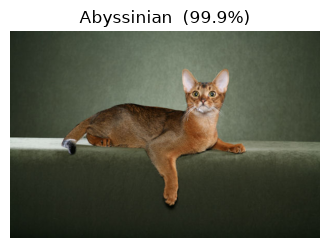

  Abyssinian                    99.9%  █████████████████████████████
  shiba_inu                      0.0%  
  Bengal                         0.0%  


In [10]:
NEW_DIR = Path.home() / "Downloads" / "new_pets"     # <- drop new images here
NEW_DIR.mkdir(parents=True, exist_ok=True)

has_new = any(p.suffix.lower() in IMG_EXT for p in NEW_DIR.rglob("*"))

if has_new:
    results = predict_folder(NEW_DIR)
else:
    print(f"No images in {NEW_DIR} yet")
    print("Drop some images there and re-run this cell. In the meantime, trying one image from the original dataset.\n")
    sample = next(p for p in (Path.home() / "Downloads" / "new_CatsandDogs").rglob("*")
                  if p.suffix.lower() in IMG_EXT)
    print(f"Test image: {sample.parent.name}/{sample.name}  (ground truth = {sample.parent.name})")
    show(sample)